In [13]:
import numpy as np

# mat = np.sum(np.load('NYC_rideshare_mob_tensor_2401.npz')['arr_0'], axis = 1)
# for mo in range(2, 13):
#     mat = np.append(mat, np.sum(np.load(f'NYC_rideshare_mob_tensor_24{mo:02d}.npz')['arr_0'], axis = 1), axis = 1)
# vec = mat.reshape(-1)
# vec = vec[vec > 0]

tensor = np.load('NYC_rideshare_mob_tensor_2401.npz')['arr_0']
for mo in range(2, 13):
    tensor = np.append(tensor, np.load(f'NYC_rideshare_mob_tensor_24{mo:02d}.npz')['arr_0'], axis = 2)
vec = tensor.reshape(-1)
vec = vec[vec > 0]

In [14]:
dist = np.zeros((int(vec.max()), 2))
dist[:, 0] = np.arange(1, vec.max() + 1)
for i in range(int(vec.max())):
    dist[i - 1, 1] = len(vec[vec == i])
ind = np.where(dist[:, 1] > 0)

# Select rows where the mask is False (i.e., not all zeros)
filtered_arr = dist[ind[0], :]
filtered_arr = filtered_arr.astype(int)

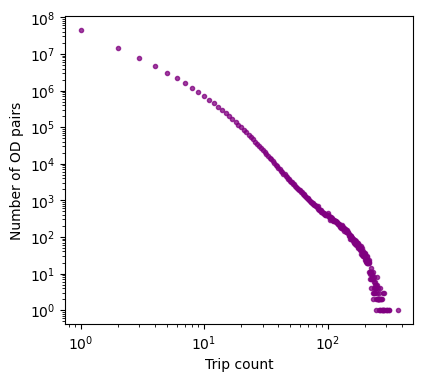

In [28]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (4.5, 4))

plt.plot(filtered_arr[:, 0], filtered_arr[:, 1], '.', color = 'purple', alpha = 0.75)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Trip count')
plt.ylabel('Number of OD pairs')
plt.show()
fig.savefig('od_dist_loglog.pdf', bbox_inches = 'tight')

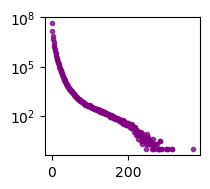

In [27]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (2, 1.8))

plt.plot(filtered_arr[:, 0], filtered_arr[:, 1], '.', color = 'purple', alpha = 0.75)
plt.yscale('log')
plt.show()
fig.savefig('od_dist_log.pdf', bbox_inches = 'tight')